# Raciocínio Espacial Neuro-Simbólico com LTNtorch

**Authors:**
- Amanda Spellen
- Lucas Darcio
- Jaide Zardin

This notebook implements the assignment **"Trabalho Final de FIA: Raciocínio Espacial Neuro-Simbólico com LTNtorch"** (see `3oTrabalho_IA.pdf`), which asks for a neuro-symbolic agent built with Logic Tensor Networks (LTN) that learns spatial relations over a simplified CLEVR-like scene.

The notebook is organized into three parts, in this order:

- **Definitions** — every function, predicate, axiom builder and model architecture used anywhere below is defined once, near the top, before it is ever called.
- **Training** — the one place where gradient descent actually happens; everything after this point only *queries* the trained grounding.
- **Evaluation** — every qualitative check, every quantitative metric, every axiom-satisfiability number, the full `df_results` dataframe, and a condensed visual report, all placed at the end.

Each section below has its own short description and is tagged with the relevant **Tarefa** from the assignment PDF.

> **Nota sobre Uso de IA**
>
> Ferramentas de IA foram usadas como apoio ao longo do trabalho: Claude para compreensão do enunciado, planejamento da solução, escrita do código e documentação; Gemini para a escrita do código.

## 1. Setup and Configuration

Imports, global constants and the random-seed helper used throughout the notebook. This section defines the "shape" of the world (5 shape classes, 3 colors, 2 sizes, feature-noise level) and the seeds used for training, held-out sanity checking, and the 5-run statistical evaluation. Nothing here is Tarefa-specific — it is shared infrastructure for everything that follows.

In [1]:
!pip install -q ltn scikit-learn

import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import functools
import ltn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from matplotlib.lines import Line2D

TRAIN_SEED = 999
TEST_SEED = 998
N_RUNS = 5
run_seeds = [0, 1, 2, 3, 42]

N_OBJECTS_PER_SHAPE = 5
SHAPES = ["circle", "square", "cylinder", "cone", "triangle"]
COLORS = ["red", "green", "blue"]
SHAPES_MAP = ["o", "s", "p", "^", "v"]
COLORS_MAP = ["red", "green", "blue"]
MIN_DIST = 0.12
FEATURE_NOISE_STD = 0.08

def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

print("Dedicated Training Seed:", TRAIN_SEED)
print("Dedicated Testing Seed:", TEST_SEED)
print("Seeds for the 5 evaluation runs:", run_seeds)



Dedicated Training Seed: 999
Dedicated Testing Seed: 998
Seeds for the 5 evaluation runs: [0, 1, 2, 3, 42]


## 2. Scene Generation and Visualization (Tarefa 1)

Implements the simplified CLEVR-like data structure required by the assignment: each object is an 11-dimensional feature vector (2D position, one-hot color, one-hot shape, one continuous size value), objects are placed without overlapping, and a small amount of Gaussian noise is added to the non-positional features to avoid predicates simply memorizing exact one-hot values. `plot_scene` renders a generated scene exactly as requested in Tarefa 1 ("Plote o cenário aleatório gerado").

In [2]:
def sample_non_overlapping_positions(n, rng, min_dist=MIN_DIST, max_tries=10_000):
    positions = []
    for _ in range(n):
        for _try in range(max_tries):
            candidate = rng.uniform(0.05, 0.95, size=2)
            if all(np.linalg.norm(candidate - p) >= min_dist for p in positions):
                positions.append(candidate)
                break
        else:
            raise RuntimeError("Could not position objects without overlap.")
    return np.array(positions)

def build_feature_vector(pos, color_idx, shape_idx, size_val):
    vec = np.zeros(11, dtype=np.float32)
    vec[0:2] = pos
    vec[2 + color_idx] = 1.0
    vec[5 + shape_idx] = 1.0
    vec[10] = size_val
    return vec

def generate_scene(seed):
    rng = np.random.default_rng(seed)
    n_total = N_OBJECTS_PER_SHAPE * len(SHAPES)
    positions = sample_non_overlapping_positions(n_total, rng)

    records = []
    idx = 0
    for shape_idx, shape in enumerate(SHAPES):
        for _ in range(N_OBJECTS_PER_SHAPE):
            color_idx = int(rng.integers(0, len(COLORS)))
            size_val = float(rng.choice([0.0, 1.0]))
            clean = build_feature_vector(positions[idx], color_idx, shape_idx, size_val)
            noisy = clean.copy()
            noisy[2:11] += rng.normal(0, FEATURE_NOISE_STD, size=9)
            records.append({
                "id": idx, "pos": positions[idx], "color": color_idx,
                "shape": shape_idx, "size": size_val,
                "clean_vec": clean, "noisy_vec": noisy.astype(np.float32),
            })
            idx += 1
    return records

def plot_scene(records, title="Scene Visualization"):
    fig, ax = plt.subplots(figsize=(6, 6))
    for r in records:
        plt.scatter(r["pos"][0], r["pos"][1],
                    c=COLORS_MAP[r["color"]],
                    marker=SHAPES_MAP[r["shape"]],
                    s=200 if r["size"] == 1.0 else 70,
                    edgecolors='k', zorder=3)
        plt.text(r["pos"][0] + 0.02, r["pos"][1] + 0.02,
                 str(r["id"]), fontsize=10, weight='bold', zorder=4)

    # Define the markers and labels that correspond to your shapes.
    # Adjust the 'marker' symbols to match exactly what your code uses.
    legend_elements = [
        Line2D(
            [0], [0],
            marker=SHAPES_MAP[i],
            color='w',
            label=sh,
            markerfacecolor='gray',
            markersize=10
        )
        for i, sh in enumerate(SHAPES)
        ]

    # Add the legend to the axes
    # loc='best' allows matplotlib to find a spot that doesn't cover your points
    # bbox_to_anchor can be used to push it outside the plot if the scene is crowded
    ax.legend(handles=legend_elements, loc='upper left',           # Which corner of the legend box to anchor
        bbox_to_anchor=(1.05, 1), title="Shape Legend")

    plt.title(title)
    plt.xlim(0, 1.05)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

## 3. Logical Connectives and Quantifiers (Fuzzy Semantics)

Grounds every logical symbol used by the axioms below with the "stable product configuration" recommended for gradient-based learning in LTN: the product t-norm for AND, the probabilistic sum for OR, the Reichenbach implication, and p-mean / p-mean-error for the existential and universal quantifiers (all with `stable=True` to avoid vanishing/exploding gradients at the 0/1 edge cases). `SatAgg` aggregates any collection of axioms into a single satisfaction value and is what every training loop below actually optimizes. This machinery is shared across Tarefas 1 through 4 — it is defined once, here.

In [3]:
Not      = ltn.Wrapper_Connective(ltn.fuzzy_ops.Not_Std())
And      = ltn.Wrapper_Connective(ltn.fuzzy_ops.And_Prod(stable=True))
Or       = ltn.Wrapper_Connective(ltn.fuzzy_ops.Or_ProbSum())
Implies  = ltn.Wrapper_Connective(ltn.fuzzy_ops.Implies_Reichenbach(stable=True))
Equiv    = ltn.Wrapper_Connective(ltn.fuzzy_ops.Equiv(
              and_op=ltn.fuzzy_ops.And_Prod(stable=True),
              implies_op=ltn.fuzzy_ops.Implies_Reichenbach(stable=True)))
Forall   = ltn.Wrapper_Quantifier(ltn.fuzzy_ops.Aggreg_pMeanError(p=2, stable=True), semantics="forall")
Exists   = ltn.Wrapper_Quantifier(ltn.fuzzy_ops.Aggreg_pMean(p=2, stable=True), semantics="exists")
SatAgg   = ltn.Wrapper_Formula_Aggregator(ltn.fuzzy_ops.Aggreg_pMeanError(p=2, stable=True))

## 4. Predicate Architecture and Training/Evaluation Utilities

Generic, task-agnostic building blocks reused everywhere below:

- `make_mlp_predicate` / `make_pairwise_predicate` — small MLP architectures for unary and binary predicates.
- `train_step` — the SatAgg-based training loop, with per-epoch logging of the worst-satisfied axioms (useful for spotting axioms being "masked" by an aggregate score).
- `eval_step` — evaluates a dictionary of axioms without updating any weights.
- `binary_metrics` — turns a predicate's continuous truth values into accuracy / precision / recall / F1 against a ground-truth label, at a 0.5 threshold.

No predicate, axiom, or task logic lives in this section — only reusable machinery.

In [4]:
def make_mlp_predicate(input_dim, hidden=16):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(hidden, activation="elu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])
    return ltn.Predicate(model)

def make_pairwise_predicate(hidden=8):
    return tf.keras.Sequential([
        tf.keras.Input(shape=(22,)),
        tf.keras.layers.Dense(hidden, activation="elu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])

def train_step(axioms_fn, trainable_vars, optimizer, epochs=300, log_every=50, tag=""):
    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            axioms_dict = axioms_fn()
            sat = SatAgg(list(axioms_dict.values()))
            loss = 1.0 - sat.tensor
        grads = tape.gradient(loss, trainable_vars)
        optimizer.apply_gradients(zip(grads, trainable_vars))

        # FIX: Granular logging per-axiom during training
        if epoch % log_every == 0:
            sat_val = sat.tensor.numpy()
            vals = {k: v.tensor.numpy() for k, v in axioms_dict.items()}
            # Print the 3 lowest performing axioms to surface masked issues
            worst_axioms = " | ".join([f"{k}: {v:.3f}" for k, v in sorted(vals.items(), key=lambda x: x[1])[:3]])
            print(f"[{tag}] Epoch {epoch:4d} | SatAgg = {sat_val:.4f}")
            print(f"         Lowest axioms: {worst_axioms}")

    return sat.tensor.numpy()

def eval_step(axioms_fn):
    axioms_dict = axioms_fn()
    return {k: v.tensor.numpy() for k, v in axioms_dict.items()}

def binary_metrics(y_true, y_pred_prob, threshold=0.5):
    y_pred = (np.asarray(y_pred_prob) > threshold).astype(int)
    y_true = np.asarray(y_true).astype(int)
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    acc = (tp + tn) / max(len(y_true), 1)
    prec = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-9)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

## 5. Taxonomy Predicates and Axioms — Shapes and Sizes (Tarefa 1)

Instantiates one MLP predicate per shape (`isCircle`, `isSquare`, `isCylinder`, `isCone`, `isTriangle`) and per size class (`isSmall`, `isBig`), and defines `build_task1_axioms`, which returns every axiom Tarefa 1 asks for: shape completeness (an object must be *some* shape), pairwise shape mutual-exclusion (an object cannot be two shapes at once), the equivalent completeness/mutex pair for size, and supervised positive/negative axioms tying each predicate to the ground-truth labels.

In [5]:
# Instantiate one MLP predicate per shape and per size class (Tarefa 1)
shape_preds = {s: make_mlp_predicate(11) for s in SHAPES}
size_preds  = {"small": make_mlp_predicate(11), "big": make_mlp_predicate(11)}


# --- Axiom Builder: Taxonomy (Tarefa 1) ---

def build_task1_axioms(records):
    all_vecs = np.stack([r["noisy_vec"] for r in records])
    x_all = ltn.Variable("x_all", all_vecs)
    named_axioms = {}

    shape_truth = [shape_preds[s](x_all) for s in SHAPES]
    combined_shape_truth = functools.reduce(Or, shape_truth)
    named_axioms["shape_completeness"] = Forall(x_all, combined_shape_truth)

    for i in range(len(SHAPES)):
        for j in range(i + 1, len(SHAPES)):
            named_axioms[f"shape_mutex_{i}_{j}"] = Forall(x_all, Not(And(shape_truth[i], shape_truth[j])))

    small_t, big_t = size_preds["small"](x_all), size_preds["big"](x_all)
    named_axioms["size_completeness"] = Forall(x_all, Or(small_t, big_t))
    named_axioms["size_mutex"] = Forall(x_all, Not(And(small_t, big_t)))

    for shape_idx, shape in enumerate(SHAPES):
        pos = [r["noisy_vec"] for r in records if r["shape"] == shape_idx]
        neg = [r["noisy_vec"] for r in records if r["shape"] != shape_idx]
        if pos:
            x_pos = ltn.Variable(f"x_{shape}_pos", np.stack(pos))
            named_axioms[f"sup_{shape}_pos"] = Forall(x_pos, shape_preds[shape](x_pos))
        if neg:
            x_neg = ltn.Variable(f"x_{shape}_neg", np.stack(neg))
            named_axioms[f"sup_{shape}_neg"] = Forall(x_neg, Not(shape_preds[shape](x_neg)))

    for size_name, size_val in [("small", 0.0), ("big", 1.0)]:
        pos = [r["noisy_vec"] for r in records if r["size"] == size_val]
        neg = [r["noisy_vec"] for r in records if r["size"] != size_val]
        if pos:
            x_pos = ltn.Variable(f"x_{size_name}_pos", np.stack(pos))
            named_axioms[f"sup_{size_name}_pos"] = Forall(x_pos, size_preds[size_name](x_pos))
        if neg:
            x_neg = ltn.Variable(f"x_{size_name}_neg", np.stack(neg))
            named_axioms[f"sup_{size_name}_neg"] = Forall(x_neg, Not(size_preds[size_name](x_neg)))

    return named_axioms



## 6. Spatial Relation Predicates and Axioms — Horizontal and Vertical Reasoning (Tarefas 2 and 3)

Defines `leftOf` / `rightOf` and `below` / `above` as two shared pairwise networks (each relation and its inverse are the *same* network called with swapped arguments, which makes the "inverse" axiom hold close to by construction), plus `closeTo`, `inBetween`, `lastOnTheLeft`, `lastOnTheRight` (Tarefa 2's horizontal reasoning) and `canStack` together with its supporting `sameSize` / `canStackGeom` predicates (Tarefa 3's vertical/stacking reasoning).

`build_spatial_axioms` is written once and reused for **both** tasks by passing the relevant coordinate axis: irreflexivity, asymmetry, the inverse equivalence, transitivity, and positive/negative supervision from the ground-truth coordinates.

In [6]:
# Instantiate the two shared pairwise networks: LeftOf/RightOf share one network (arguments swapped),
# and Below/Above share the other -- this makes the 'inverse' axiom hold by construction.
leftof_model = make_pairwise_predicate()
below_model = make_pairwise_predicate()


# --- Derived Predicates (Now taking full 11-D vectors) ---
LeftOf = ltn.Predicate.Lambda(lambda args: tf.squeeze(leftof_model(tf.concat([args[0], args[1]], axis=1)), axis=1))
RightOf = ltn.Predicate.Lambda(lambda args: tf.squeeze(leftof_model(tf.concat([args[1], args[0]], axis=1)), axis=1))
Below = ltn.Predicate.Lambda(lambda args: tf.squeeze(below_model(tf.concat([args[0], args[1]], axis=1)), axis=1))
Above = ltn.Predicate.Lambda(lambda args: tf.squeeze(below_model(tf.concat([args[1], args[0]], axis=-1)), axis=-1))
CloseTo = ltn.Predicate.Lambda(lambda args: tf.exp(-2.0 * tf.reduce_sum(tf.square(args[0][..., :2] - args[1][..., :2]), axis=-1)))
SameSize = ltn.Predicate.Lambda(lambda args: 1.0 - tf.abs(args[0][..., 10] - args[1][..., 10]))
CanStackGeom = ltn.Predicate.Lambda(lambda args: tf.exp(-4.0 * tf.abs(args[0][..., 0] - args[1][..., 0])))
IsGreen = ltn.Predicate.Lambda(lambda x: x[..., 3])

def InBetween(x, y, z):
    return Or(And(LeftOf([y, x]), RightOf([z, x])), And(LeftOf([z, x]), RightOf([y, x])))

def LastOnTheLeft(x_obj, y_obj):
    return Exists(x_obj, Forall(y_obj, LeftOf([x_obj, y_obj])))

def LastOnTheRight(x_obj, y_obj):
    return Exists(x_obj, Forall(y_obj, RightOf([x_obj, y_obj])))

def CanStack(x_obj, y_obj):
    not_cone_y = Not(shape_preds["cone"](y_obj))
    not_tri_y  = Not(shape_preds["triangle"](y_obj))
    return And(And(not_cone_y, not_tri_y), CanStackGeom([x_obj, y_obj]))

# --- Axiom Builder: Spatial Relations, reused for both the horizontal axis (Tarefa 2)
# and the vertical axis (Tarefa 3) via the `axis_idx` parameter ---

def build_spatial_axioms(records, axis_idx, predicate, inverse_pred):
    all_vecs = np.stack([r["noisy_vec"] for r in records])
    positions = np.stack([r["pos"] for r in records]).astype(np.float32)
    n = len(records)
    idx_pairs = [(i, j) for i in range(n) for j in range(n) if i != j]

    x = ltn.Variable("x", all_vecs)
    y = ltn.Variable("y", all_vecs)
    z = ltn.Variable("z", all_vecs)

    named = {
        "irreflexivity": Forall(x, Not(predicate([x, x]))),
        "asymmetry": Forall([x, y], Implies(predicate([x, y]), Not(predicate([y, x])))),
        "inverse": Forall([x, y], Equiv(predicate([x, y]), inverse_pred([y, x]))),
        "transitivity": Forall([x, y, z], Implies(And(predicate([x, y]), predicate([y, z])), predicate([x, z]))),
    }

    pos_pairs = [(i, j) for i, j in idx_pairs if positions[i, axis_idx] < positions[j, axis_idx]]
    neg_pairs = [(i, j) for i, j in idx_pairs if positions[i, axis_idx] >= positions[j, axis_idx]]

    if pos_pairs:
        a_pos = ltn.Variable("a_pos", all_vecs[[p[0] for p in pos_pairs]])
        b_pos = ltn.Variable("b_pos", all_vecs[[p[1] for p in pos_pairs]])
        named["supervision_pos"] = Forall(ltn.diag(a_pos, b_pos), predicate([a_pos, b_pos]))

    if neg_pairs:
        a_neg = ltn.Variable("a_neg", all_vecs[[p[0] for p in neg_pairs]])
        b_neg = ltn.Variable("b_neg", all_vecs[[p[1] for p in neg_pairs]])
        named["supervision_neg"] = Forall(ltn.diag(a_neg, b_neg), Not(predicate([a_neg, b_neg])))

    return named



## 7. Compound Reasoning Queries and Explanations (Tarefa 4)

`task4_queries` formalizes the three composed queries requested by Tarefa 4: the compound filter ("a small object below a cylinder and left of a square"), the green-cone `inBetween` deduction, and the proximity-implies-same-size restriction on triangles.

`explain_task4_and_formulas` is the notebook's explainability (XAI) component — the assignment's "Ponto Extra" — producing an object-level, human-readable justification for `lastOnTheLeft` and for each Task 4 query, rather than only a single aggregate truth value.

In [7]:
def task4_queries(records):
    all_vecs = np.stack([r["noisy_vec"] for r in records])
    x_o, y_o, z_o = [ltn.Variable(f"{n}_o", all_vecs) for n in "xyz"]

    # 1. Compound filtering query
    q1 = Exists([x_o],
          And(size_preds["small"](x_o),
              And(Exists([y_o], And(shape_preds["cylinder"](y_o), Below([x_o, y_o]))),
                  Exists([z_o], And(shape_preds["square"](z_o), LeftOf([x_o, z_o]))))))

    # 2. Green cone InBetween query
    q2 = Exists([x_o, y_o, z_o],
          And(And(shape_preds["cone"](x_o), IsGreen(x_o)), InBetween(x_o, y_o, z_o)))

    # 3. Proximity constraint (Nearby triangles must share the same size)
    q3 = Forall([x_o, y_o],
          Implies(And(And(shape_preds["triangle"](x_o), shape_preds["triangle"](y_o)), CloseTo([x_o, y_o])),
                  SameSize([x_o, y_o])))
    return q1.tensor.numpy(), q2.tensor.numpy(), q3.tensor.numpy()

def explain_task4_and_formulas(records):
    all_vecs = np.stack([r["noisy_vec"] for r in records]).astype(np.float32)
    positions = np.stack([r["pos"] for r in records]).astype(np.float32)
    n = len(records)

    print("\n--- XAI EXPLANATIONS ---")

    # 1. Explain Last On The Left
    scores_left = []
    for i in range(n):
        xi = ltn.Constant(all_vecs[i], trainable=False)
        all_objs = ltn.Variable("all_objs", all_vecs)
        val = Forall(all_objs, LeftOf([xi, all_objs])).tensor.numpy()
        scores_left.append(val)
    best_left = int(np.argmax(scores_left))
    print(f"--> [LastOnTheLeft] Object {best_left} is furthest left. Confidence: {scores_left[best_left]:.3f} (Pos: {positions[best_left]})")

    # 2. Explain Task 4 Query 1 (Compound Filter)
    scores_q1 = []
    for i in range(n):
        xi = ltn.Constant(all_vecs[i], trainable=False)
        y = ltn.Variable("y", all_vecs)
        z = ltn.Variable("z", all_vecs)
        val = And(size_preds["small"](xi),
                  And(Exists(y, And(shape_preds["cylinder"](y), Below([xi, y]))),
                      Exists(z, And(shape_preds["square"](z), LeftOf([xi, z]))))).tensor.numpy()
        scores_q1.append(val)
    best_q1 = int(np.argmax(scores_q1))
    print(f"--> [Query 1] Object {best_q1} best satisfies the 'Small AND (Cylinder Below) AND (Square Left)' criteria. Score: {scores_q1[best_q1]:.3f}")

    # 3. Explain Task 4 Query 3 (Triangle Proximity Constraint)
    triangles = [r for r in records if r["shape"] == SHAPES.index("triangle")]
    if len(triangles) >= 2:
        min_dist = float('inf')
        best_pair = None
        for i in range(len(triangles)):
            for j in range(i+1, len(triangles)):
                d = np.linalg.norm(triangles[i]["pos"] - triangles[j]["pos"])
                if d < min_dist:
                    min_dist = d
                    best_pair = (triangles[i], triangles[j])

        t1, t2 = best_pair

        # Pass the raw 1D feature vectors directly into ltn.Constant
        c1 = ltn.Constant(t1["noisy_vec"], trainable=False)
        c2 = ltn.Constant(t2["noisy_vec"], trainable=False)

        # Evaluate predicate safely across any broadcast dimensions
        is_same = SameSize([c1, c2]).tensor.numpy()
        if is_same.ndim > 0:
            is_same = is_same.ravel()[0]

        print(f"--> [Query 3] Closest triangles are Obj {t1['id']} & Obj {t2['id']} (Distance: {min_dist:.3f}). "
              f"Network's 'SameSize' truth value for this pair: {is_same:.3f}")

## 8. Training (Tarefas 1, 2 and 3)

The only place in the notebook where gradients are computed and weights are updated. All predicates are trained **once**, on a single dedicated scene (`TRAIN_SEED`), by maximizing `SatAgg` over each task's axioms — first the taxonomy axioms (Tarefa 1), then the horizontal spatial axioms (Tarefa 2), then the vertical spatial axioms (Tarefa 3). Every section from this point on only queries the resulting grounding; none of them modify any weights.

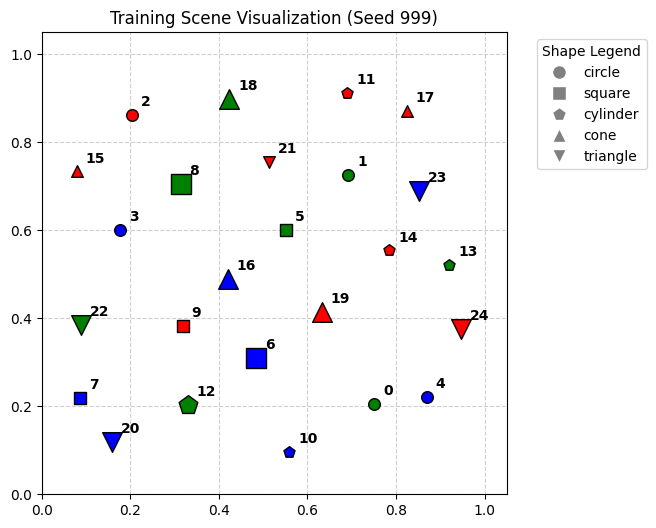

=== Training Phase (Seed 999) ===
[Task1] Epoch    0 | SatAgg = 0.6060
         Lowest axioms: sup_big_pos: 0.403 | sup_square_pos: 0.407 | sup_small_neg: 0.438
[Task1] Epoch   50 | SatAgg = 0.9672
         Lowest axioms: sup_small_pos: 0.931 | sup_small_neg: 0.931 | sup_big_pos: 0.941
[Task1] Epoch  100 | SatAgg = 0.9960
         Lowest axioms: sup_small_neg: 0.994 | sup_small_pos: 0.994 | size_completeness: 0.994
[Task1] Epoch  150 | SatAgg = 0.9982
         Lowest axioms: sup_small_neg: 0.997 | sup_small_pos: 0.997 | size_completeness: 0.997
[Task1] Epoch  200 | SatAgg = 0.9989
         Lowest axioms: size_completeness: 0.998 | sup_small_neg: 0.998 | sup_small_pos: 0.998
[Task1] Epoch  250 | SatAgg = 0.9992
         Lowest axioms: size_completeness: 0.999 | size_mutex: 0.999 | sup_small_neg: 0.999
[Task2-LeftOf] Epoch    0 | SatAgg = 0.5834
         Lowest axioms: supervision_neg: 0.480 | irreflexivity: 0.484 | supervision_pos: 0.507
[Task2-LeftOf] Epoch   50 | SatAgg = 0.6902
     

np.float32(0.94339925)

In [8]:
# Execute Training ONCE on the Dedicated Seed
set_all_seeds(TRAIN_SEED)
train_records = generate_scene(TRAIN_SEED)
plot_scene(train_records, title=f"Training Scene Visualization (Seed {TRAIN_SEED})")

print(f"=== Training Phase (Seed {TRAIN_SEED}) ===")
vars_t1 = sum([p.trainable_variables for p in shape_preds.values()], []) + sum([p.trainable_variables for p in size_preds.values()], [])
train_step(lambda: build_task1_axioms(train_records), vars_t1, tf.keras.optimizers.Adam(0.01), epochs=300, tag="Task1")
train_step(lambda: build_spatial_axioms(train_records, 0, LeftOf, RightOf), leftof_model.trainable_variables, tf.keras.optimizers.Adam(0.01), epochs=300, tag="Task2-LeftOf")
train_step(lambda: build_spatial_axioms(train_records, 1, Below, Above), below_model.trainable_variables, tf.keras.optimizers.Adam(0.01), epochs=300, tag="Task3-Below")

## 9. Evaluation

Everything below is read-only with respect to the trained models. Evaluation happens in three stages: a quick qualitative sanity check on known scenes, a quantitative multi-seed run that builds the `df_results` dataframe, and finally a presentation of that dataframe — first as complete tables (every column, every row), then as a condensed visual report.

### 9.1 Qualitative Sanity Check — Training and Held-out Scenarios (Tarefas 2, 3 and 4)

Before running the full statistical evaluation, this section manually inspects the training scene and one fixed, never-trained-on scene (`TEST_SEED`), printing the Task 4 query scores and the XAI explanations for both. This is a quick, human-readable check that the learned grounding behaves sensibly before trusting the aggregate numbers computed next.


Evaluating Train Scenario (Seed: 999)


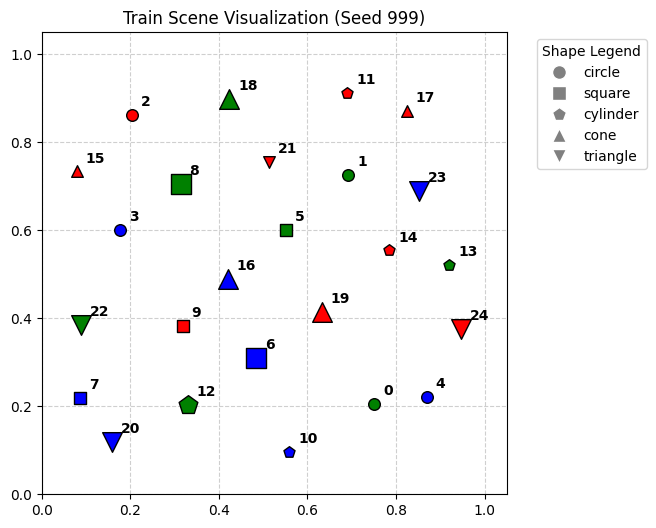


--- TASK 4 QUERIES ---
Query 1 (Compound Filter) Aggregation Score: 0.0438
Query 2 (Green Cone InBetween) Aggregation Score: 0.1240
Query 3 (Triangle Proximity Constraint) Aggregation Score: 0.9466

--- XAI EXPLANATIONS ---
--> [LastOnTheLeft] Object 15 is furthest left. Confidence: 0.799 (Pos: [0.07885701 0.7339567 ])
--> [Query 1] Object 7 best satisfies the 'Small AND (Cylinder Below) AND (Square Left)' criteria. Score: 0.138
--> [Query 3] Closest triangles are Obj 20 & Obj 22 (Distance: 0.274). Network's 'SameSize' truth value for this pair: 0.983

Evaluating Test Scenario (Seed: 998)


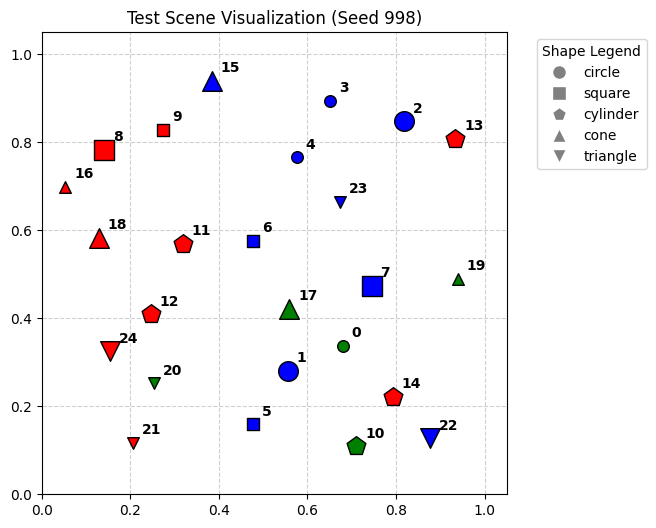


--- TASK 4 QUERIES ---
Query 1 (Compound Filter) Aggregation Score: 0.0439
Query 2 (Green Cone InBetween) Aggregation Score: 0.1490
Query 3 (Triangle Proximity Constraint) Aggregation Score: 0.8954

--- XAI EXPLANATIONS ---
--> [LastOnTheLeft] Object 16 is furthest left. Confidence: 0.783 (Pos: [0.05294858 0.6987948 ])
--> [Query 1] Object 21 best satisfies the 'Small AND (Cylinder Below) AND (Square Left)' criteria. Score: 0.149
--> [Query 3] Closest triangles are Obj 20 & Obj 24 (Distance: 0.122). Network's 'SameSize' truth value for this pair: -0.265


In [9]:
scenarios = [(TRAIN_SEED, "Train"), (TEST_SEED, "Test")]

for seed_val, scenario_name in scenarios:
    print(f"\n{'='*50}")
    print(f"Evaluating {scenario_name} Scenario (Seed: {seed_val})")
    print(f"{'='*50}")

    # 1. Set seeds and generate the scene records
    set_all_seeds(seed_val)
    eval_records = generate_scene(seed_val)

    # 2. Plot the scenario (Plot)
    plot_scene(eval_records, title=f"{scenario_name} Scene Visualization (Seed {seed_val})")

    # 3. Evaluate Queries
    print("\n--- TASK 4 QUERIES ---")
    q1, q2, q3 = task4_queries(eval_records)
    print(f"Query 1 (Compound Filter) Aggregation Score: {q1:.4f}")
    print(f"Query 2 (Green Cone InBetween) Aggregation Score: {q2:.4f}")
    print(f"Query 3 (Triangle Proximity Constraint) Aggregation Score: {q3:.4f}")

    # 4. Evaluate Formulas / XAI Explanations
    explain_task4_and_formulas(eval_records)

### 9.2 Quantitative Multi-Seed Evaluation — Building `df_results` (Tarefas 1, 2, 3 and 4)

Fits a Logistic Regression baseline once on the training scene (for comparison against the LTN predicates), then re-evaluates everything — per-shape and per-size classification metrics, spatial-relation metrics including `canStack`, every axiom's satisfiability, and the Task 4 queries/formulas — across five independently generated scenes (`run_seeds`). Every value computed in this loop is collected into `df_results`, which is the single source of truth for every result presented from here on.


=== Evaluation Phase (5 Different Scenarios) ===


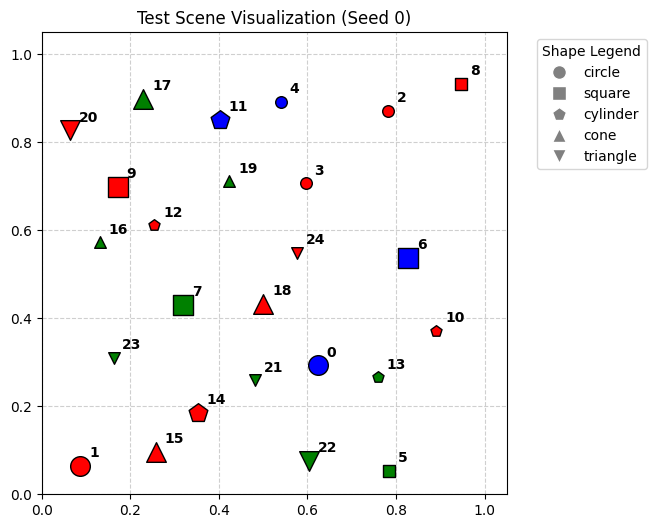


--- XAI EXPLANATIONS ---
--> [LastOnTheLeft] Object 20 is furthest left. Confidence: 0.715 (Pos: [0.06323568 0.8272761 ])
--> [Query 1] Object 1 best satisfies the 'Small AND (Cylinder Below) AND (Square Left)' criteria. Score: 0.174
--> [Query 3] Closest triangles are Obj 21 & Obj 22 (Distance: 0.220). Network's 'SameSize' truth value for this pair: 0.068


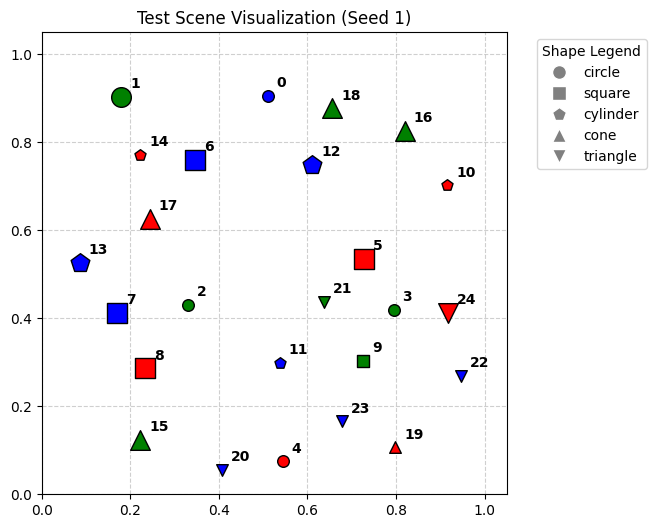


--- XAI EXPLANATIONS ---
--> [LastOnTheLeft] Object 13 is furthest left. Confidence: 0.812 (Pos: [0.08563359 0.5257303 ])
--> [Query 1] Object 4 best satisfies the 'Small AND (Cylinder Below) AND (Square Left)' criteria. Score: 0.121
--> [Query 3] Closest triangles are Obj 22 & Obj 24 (Distance: 0.145). Network's 'SameSize' truth value for this pair: -0.016


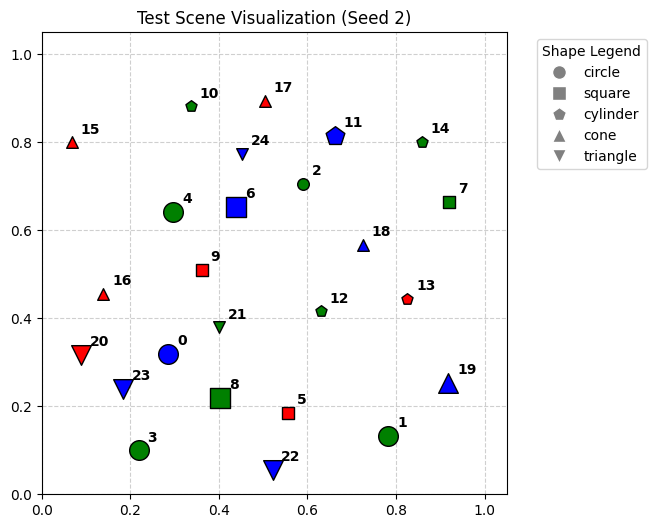


--- XAI EXPLANATIONS ---
--> [LastOnTheLeft] Object 15 is furthest left. Confidence: 0.777 (Pos: [0.06791967 0.7996973 ])
--> [Query 1] Object 16 best satisfies the 'Small AND (Cylinder Below) AND (Square Left)' criteria. Score: 0.167
--> [Query 3] Closest triangles are Obj 20 & Obj 23 (Distance: 0.123). Network's 'SameSize' truth value for this pair: 0.946


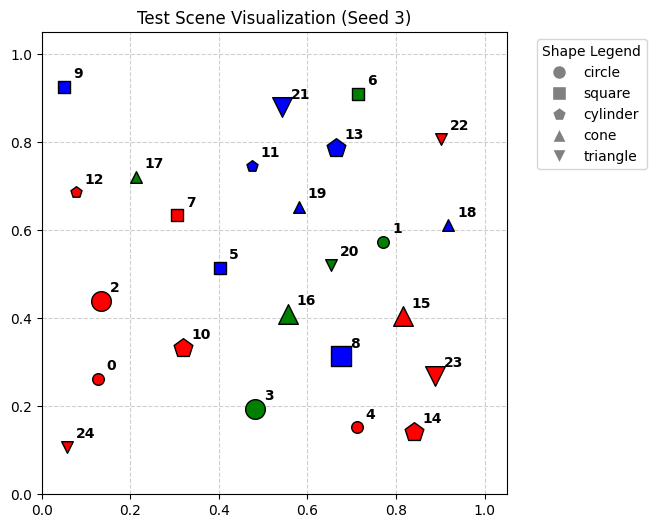


--- XAI EXPLANATIONS ---
--> [LastOnTheLeft] Object 9 is furthest left. Confidence: 0.774 (Pos: [0.05134108 0.92611426])
--> [Query 1] Object 0 best satisfies the 'Small AND (Cylinder Below) AND (Square Left)' criteria. Score: 0.141
--> [Query 3] Closest triangles are Obj 20 & Obj 23 (Distance: 0.345). Network's 'SameSize' truth value for this pair: 0.016


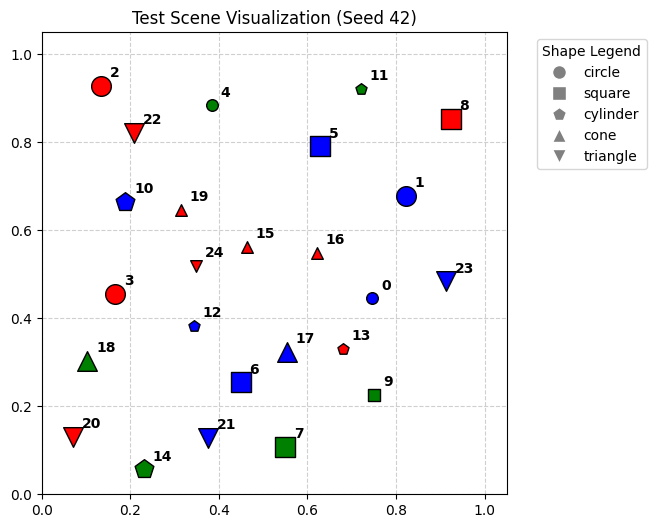


--- XAI EXPLANATIONS ---
--> [LastOnTheLeft] Object 18 is furthest left. Confidence: 0.729 (Pos: [0.10247247 0.3032455 ])
--> [Query 1] Object 12 best satisfies the 'Small AND (Cylinder Below) AND (Square Left)' criteria. Score: 0.123
--> [Query 3] Closest triangles are Obj 20 & Obj 21 (Distance: 0.305). Network's 'SameSize' truth value for this pair: 0.900


In [10]:
print("\n=== Evaluation Phase (5 Different Scenarios) ===")
all_results = []

# --- BASELINE LOGISTIC REGRESSION TRAINING ---
X_train = np.stack([r["noisy_vec"] for r in train_records])
y_train_shape = [r["shape"] for r in train_records]
y_train_size = [r["size"] for r in train_records]

lr_shape = LogisticRegression(max_iter=1000).fit(X_train, y_train_shape)
lr_size = LogisticRegression(max_iter=1000).fit(X_train, y_train_size)

for s in run_seeds:
    seed = int(s)
    set_all_seeds(seed)
    test_records = generate_scene(seed)

    # if seed == run_seeds[0]:
    plot_scene(test_records, title=f"Test Scene Visualization (Seed {seed})")
    explain_task4_and_formulas(test_records)

    all_vecs = np.stack([r["noisy_vec"] for r in test_records])
    x_eval = ltn.Variable("x_eval", all_vecs)
    positions = np.stack([r["pos"] for r in test_records]).astype(np.float32)

    row = {"eval_seed": seed}

    # 0. Baseline Metrics
    row["baseline_shape_acc"] = accuracy_score([r["shape"] for r in test_records], lr_shape.predict(all_vecs))
    row["baseline_size_acc"] = accuracy_score([r["size"] for r in test_records], lr_size.predict(all_vecs))

    # 1. Classification Metrics (Per-shape and Per-size)
    for shape_idx, shape in enumerate(SHAPES):
        y_true = [1 if r["shape"] == shape_idx else 0 for r in test_records]
        y_prob = shape_preds[shape](x_eval).tensor.numpy()
        for k, v in binary_metrics(y_true, y_prob).items():
            row[f"{shape}_{k}"] = v

    for size_name, size_val in [("small", 0.0), ("big", 1.0)]:
        y_true = [1 if r["size"] == size_val else 0 for r in test_records]
        y_prob = size_preds[size_name](x_eval).tensor.numpy()
        for k, v in binary_metrics(y_true, y_prob).items():
            row[f"{size_name}_{k}"] = v

    # 2. Spatial Metrics (LeftOf, Below, CanStack)
    n = len(test_records)
    idx_pairs = [(i, j) for i in range(n) for j in range(n) if i != j]
    a_eval = ltn.Variable("a_eval", all_vecs[[p[0] for p in idx_pairs]])
    b_eval = ltn.Variable("b_eval", all_vecs[[p[1] for p in idx_pairs]])
    ltn.diag(a_eval, b_eval)

    y_true_left = [1 if positions[i,0] < positions[j,0] else 0 for i,j in idx_pairs]
    y_true_below = [1 if positions[i,1] < positions[j,1] else 0 for i,j in idx_pairs]

    # Ground Truth CanStack (y not cone/triangle, and x-distance < 0.15)
    y_true_stack = []
    for i, j in idx_pairs:
        obj_x, obj_y = test_records[i], test_records[j]
        not_cone_tri = obj_y["shape"] not in [3, 4]
        close_x = abs(obj_x["pos"][0] - obj_y["pos"][0]) < 0.15
        y_true_stack.append(1 if (not_cone_tri and close_x) else 0)

    for k, v in binary_metrics(y_true_left, LeftOf([a_eval, b_eval]).tensor.numpy()).items():
        row[f"leftOf_{k}"] = v
    for k, v in binary_metrics(y_true_below, Below([a_eval, b_eval]).tensor.numpy()).items():
        row[f"below_{k}"] = v
    for k, v in binary_metrics(y_true_stack, CanStack(a_eval, b_eval).tensor.numpy()).items():
        row[f"canStack_{k}"] = v

    # 3. Satisfiability PER AXIOM (Granular Dictionaries)
    sat1_dict = eval_step(lambda: build_task1_axioms(test_records))
    sat2_dict = eval_step(lambda: build_spatial_axioms(test_records, 0, LeftOf, RightOf))
    sat3_dict = eval_step(lambda: build_spatial_axioms(test_records, 1, Below, Above))

    for k, v in sat1_dict.items(): row[f"sat1_{k}"] = v
    for k, v in sat2_dict.items(): row[f"sat2_leftOf_{k}"] = v
    for k, v in sat3_dict.items(): row[f"sat3_below_{k}"] = v

    # 4. Task 4 Queries & Specific Formulas
    q1, q2, q3 = task4_queries(test_records)
    row["query1_sat"] = q1
    row["query2_sat"] = q2
    row["query3_sat"] = q3

    # FIX: Create a distinct second variable for the y_obj argument
    y_eval = ltn.Variable("y_eval", all_vecs)

    # Pass x_eval and y_eval separately
    row["formula_lastOnTheLeft"] = LastOnTheLeft(x_eval, y_eval).tensor.numpy()
    row["formula_lastOnTheRight"] = LastOnTheRight(x_eval, y_eval).tensor.numpy()

    all_results.append(row)

df_results = pd.DataFrame(all_results)


### 9.3 Complete Results Tables — All `df_results` Columns (Tarefas 1, 2, 3 and 4)

Every column produced by the evaluation loop above is rendered here, split into readable groups: baselines and overall classification, one table per shape, size and spatial metrics (including `canStack`), Task 4 queries and explicit formulas, the full Task 1 axiom satisfiability (completeness, mutual exclusion and supervision for every shape/size), and the full Task 2/3 axiom satisfiability (irreflexivity, asymmetry, inverse, transitivity and supervision for `leftOf` and `below`). Nothing computed above is left out of this notebook.

In [11]:
pd.set_option('display.max_columns', None)

print("\n" + "="*50)
print("BASELINES & OVERALL CLASSIFICATION (Tarefa 1)")
print("="*50)
baseline_cols = ["eval_seed", "baseline_shape_acc", "baseline_size_acc"]
print("\n--- LINEAR REGRESSION BASELINES ---")
print(df_results[baseline_cols].to_markdown(index=False))

for shape in SHAPES:
    shape_cols = ["eval_seed"] + [c for c in df_results.columns if c.startswith(f"{shape}_")]
    print(f"\n--- {shape.upper()} (Tarefa 1) ---")
    print(df_results[shape_cols].to_markdown(index=False))

print("\n" + "="*50)
print("SIZE & SPATIAL METRICS (Tarefas 1-3)")
print("="*50)
size_cols = ["eval_seed"] + [c for c in df_results.columns if c.startswith("small_") or c.startswith("big_")]
print("\n--- SIZES (Tarefa 1) ---")
print(df_results[size_cols].to_markdown(index=False))

spatial_cols = ["eval_seed"] + [c for c in df_results.columns if c.startswith("leftOf_") or c.startswith("below_") or c.startswith("canStack_")]
print("\n--- SPATIAL RELATIONS, inc. CanStack (Tarefas 2 & 3) ---")
print(df_results[spatial_cols].to_markdown(index=False))

print("\n" + "="*50)
print("AXIOM SATISFIABILITY & FORMULAS (Tarefas 1-4)")
print("="*50)

query_cols = ["eval_seed"] + [c for c in df_results.columns if c.startswith("query") or c.startswith("formula")]
print("\n--- TASK 4 QUERIES & FORMULAS (Tarefa 4) ---")
print(df_results[query_cols].to_markdown(index=False))

sat1_cols = ["eval_seed"] + [c for c in df_results.columns if c.startswith("sat1_")]
print("\n--- TASK 1 AXIOMS: Shapes & Sizes (Tarefa 1) ---")
print(df_results[sat1_cols].to_markdown(index=False))

sat23_cols = ["eval_seed"] + [c for c in df_results.columns if c.startswith("sat2_") or c.startswith("sat3_")]
print("\n--- TASKS 2 & 3 AXIOMS: Spatial (Tarefas 2 & 3) ---")
print(df_results[sat23_cols].to_markdown(index=False))


BASELINES & OVERALL CLASSIFICATION (Tarefa 1)

--- LINEAR REGRESSION BASELINES ---
|   eval_seed |   baseline_shape_acc |   baseline_size_acc |
|------------:|---------------------:|--------------------:|
|           0 |                    1 |                0.92 |
|           1 |                    1 |                1    |
|           2 |                    1 |                1    |
|           3 |                    1 |                0.92 |
|          42 |                    1 |                0.96 |

--- CIRCLE (Tarefa 1) ---
|   eval_seed |   circle_accuracy |   circle_precision |   circle_recall |   circle_f1 |
|------------:|------------------:|-------------------:|----------------:|------------:|
|           0 |                 1 |                  1 |               1 |           1 |
|           1 |                 1 |                  1 |               1 |           1 |
|           2 |                 1 |                  1 |               1 |           1 |
|           3 |  

### 9.4 Visual Report and Summary Dashboard

A condensed, chart-based summary of the same `df_results` data — mean and standard deviation across the five evaluation seeds — meant for quick visual inspection and for pasting directly into the written report. This complements, and does not replace, the complete tables in the previous section.

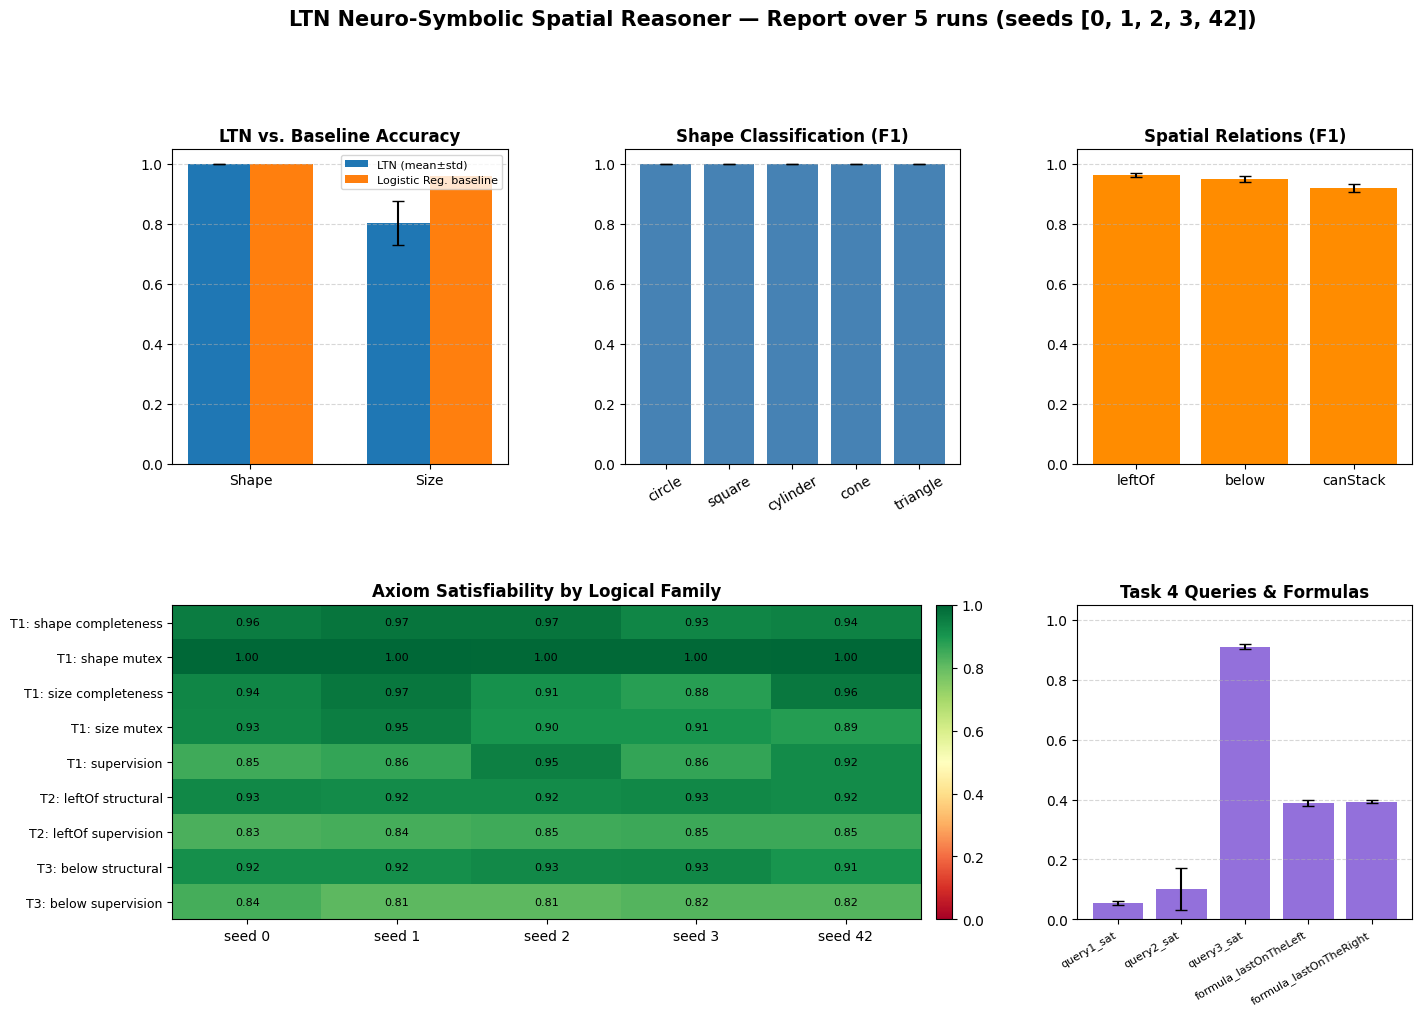

,accuracy,precision,recall,f1
circle,1.000,1.000,1.000,1.000
square,1.000,1.000,1.000,1.000
cylinder,1.000,1.000,1.000,1.000
cone,1.000,1.000,1.000,1.000
triangle,1.000,1.000,1.000,1.000
small,0.800,0.826,0.795,0.802
big,0.808,0.784,0.837,0.804
leftOf,0.965,0.982,0.947,0.964
below,0.952,0.965,0.938,0.951
canStack,0.973,0.855,1.000,0.922



KEY FINDINGS (auto-generated from this run)
--------------------------------------------
- Best-learned shape predicate:  circle  (F1=1.000 ± 0.000)
- Weakest shape predicate:       circle (F1=1.000 ± 0.000)
- LTN vs. baseline gap (shape):  +0.000
- LTN vs. baseline gap (size):   -0.156
- Most stable predicate across seeds:  circle (std=0.000)
- Least stable predicate across seeds: circle (std=0.000)



In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import re

pd.set_option('display.max_columns', None)

# ---------- helpers ----------
def group_mean_std(df, names, suffix):
    """mean/std across seeds for columns like f'{name}_{suffix}'."""
    out = {}
    for n in names:
        col = f"{n}_{suffix}"
        if col in df.columns:
            out[n] = (df[col].mean(), df[col].std())
    return out

def sat_family_means(df, pattern):
    """Average, per seed, all sat-columns whose name matches `pattern`,
    then return the mean/std of that per-seed average across seeds."""
    cols = [c for c in df.columns if re.search(pattern, c)]
    if not cols:
        return None
    per_seed = df[cols].mean(axis=1)
    return per_seed.mean(), per_seed.std(), cols

# ---------- 1. Dashboard figure ----------
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# (A) LTN vs. baseline (shape & size)
ax = fig.add_subplot(gs[0, 0])
ltn_shape = df_results[[f"{s}_accuracy" for s in SHAPES]].mean(axis=1)
ltn_size  = df_results[["small_accuracy", "big_accuracy"]].mean(axis=1)
groups   = ["Shape", "Size"]
ltn_vals = [ltn_shape.mean(), ltn_size.mean()]
ltn_errs = [ltn_shape.std(),  ltn_size.std()]
base_vals = [df_results["baseline_shape_acc"].mean(), df_results["baseline_size_acc"].mean()]
x = np.arange(len(groups)); w = 0.35
ax.bar(x - w/2, ltn_vals, w, yerr=ltn_errs, capsize=4, label="LTN (mean±std)")
ax.bar(x + w/2, base_vals, w, label="Logistic Reg. baseline")
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylim(0, 1.05); ax.set_title("LTN vs. Baseline Accuracy", weight="bold")
ax.legend(fontsize=8); ax.grid(axis="y", ls="--", alpha=0.5)

# (B) Shape predicate F1
ax = fig.add_subplot(gs[0, 1])
shape_f1 = group_mean_std(df_results, SHAPES, "f1")
names = list(shape_f1); means = [shape_f1[n][0] for n in names]; stds = [shape_f1[n][1] for n in names]
ax.bar(names, means, yerr=stds, capsize=4, color="steelblue")
ax.set_ylim(0, 1.05); ax.set_title("Shape Classification (F1)", weight="bold")
ax.tick_params(axis='x', rotation=30); ax.grid(axis="y", ls="--", alpha=0.5)

# (C) Spatial relation F1 (leftOf / below / canStack)
ax = fig.add_subplot(gs[0, 2])
spatial_f1 = group_mean_std(df_results, ["leftOf", "below", "canStack"], "f1")
names = list(spatial_f1); means = [spatial_f1[n][0] for n in names]; stds = [spatial_f1[n][1] for n in names]
ax.bar(names, means, yerr=stds, capsize=4, color="darkorange")
ax.set_ylim(0, 1.05); ax.set_title("Spatial Relations (F1)", weight="bold")
ax.grid(axis="y", ls="--", alpha=0.5)

# (D) Axiom-family satisfiability heatmap (Task 1/2/3), averaged into logical families
families = {
    "T1: shape completeness": r"sat1_shape_completeness",
    "T1: shape mutex":        r"sat1_shape_mutex",
    "T1: size completeness":  r"sat1_size_completeness",
    "T1: size mutex":         r"sat1_size_mutex",
    "T1: supervision":        r"sat1_sup_",
    "T2: leftOf structural":  r"sat2_leftOf_(irreflexivity|asymmetry|inverse|transitivity)",
    "T2: leftOf supervision": r"sat2_leftOf_supervision",
    "T3: below structural":   r"sat3_below_(irreflexivity|asymmetry|inverse|transitivity)",
    "T3: below supervision":  r"sat3_below_supervision",
}
heat_rows, heat_labels = [], []
for label, pat in families.items():
    cols = [c for c in df_results.columns if re.search(pat, c)]
    if cols:
        heat_rows.append(df_results[cols].mean(axis=1).values)
        heat_labels.append(label)
heat_data = np.array(heat_rows)

ax = fig.add_subplot(gs[1, 0:2])
im = ax.imshow(heat_data, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_yticks(range(len(heat_labels))); ax.set_yticklabels(heat_labels, fontsize=9)
ax.set_xticks(range(len(df_results))); ax.set_xticklabels([f"seed {s}" for s in df_results["eval_seed"]])
for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        ax.text(j, i, f"{heat_data[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Axiom Satisfiability by Logical Family", weight="bold")
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)

# (E) Task 4 queries + explicit formulas
ax = fig.add_subplot(gs[1, 2])
q_cols = ["query1_sat", "query2_sat", "query3_sat", "formula_lastOnTheLeft", "formula_lastOnTheRight"]
q_cols = [c for c in q_cols if c in df_results.columns]
means = df_results[q_cols].mean(); stds = df_results[q_cols].std()
ax.bar(range(len(q_cols)), means, yerr=stds, capsize=4, color="mediumpurple")
ax.set_xticks(range(len(q_cols))); ax.set_xticklabels(q_cols, rotation=30, ha="right", fontsize=8)
ax.set_ylim(0, 1.05); ax.set_title("Task 4 Queries & Formulas", weight="bold")
ax.grid(axis="y", ls="--", alpha=0.5)

fig.suptitle(f"LTN Neuro-Symbolic Spatial Reasoner — Report over {len(df_results)} runs "
             f"(seeds {list(df_results['eval_seed'])})", fontsize=15, weight="bold", y=1.02)
plt.show()

# ---------- 2. Color-coded summary table (great for pasting into the Markdown/PDF report) ----------
summary_rows = {}
for s in SHAPES:
    summary_rows[s] = {m: df_results[f"{s}_{m}"].mean() for m in ["accuracy","precision","recall","f1"]}
for s in ["small","big"]:
    summary_rows[s] = {m: df_results[f"{s}_{m}"].mean() for m in ["accuracy","precision","recall","f1"]}
for s in ["leftOf","below","canStack"]:
    summary_rows[s] = {m: df_results[f"{s}_{m}"].mean() for m in ["accuracy","precision","recall","f1"]}
summary_df = pd.DataFrame(summary_rows).T
display(summary_df.style.background_gradient(cmap="RdYlGn", vmin=0, vmax=1).format("{:.3f}")
        .set_caption("Mean classification metrics across all runs"))

# ---------- 3. Auto-generated narrative (data-driven, not hard-coded) ----------
best_shape = max(shape_f1, key=lambda k: shape_f1[k][0])
worst_shape = min(shape_f1, key=lambda k: shape_f1[k][0])
gap_shape = ltn_shape.mean() - df_results["baseline_shape_acc"].mean()
gap_size  = ltn_size.mean()  - df_results["baseline_size_acc"].mean()
most_stable = min(shape_f1, key=lambda k: shape_f1[k][1])
least_stable = max(shape_f1, key=lambda k: shape_f1[k][1])

print(f"""
KEY FINDINGS (auto-generated from this run)
--------------------------------------------
- Best-learned shape predicate:  {best_shape}  (F1={shape_f1[best_shape][0]:.3f} ± {shape_f1[best_shape][1]:.3f})
- Weakest shape predicate:       {worst_shape} (F1={shape_f1[worst_shape][0]:.3f} ± {shape_f1[worst_shape][1]:.3f})
- LTN vs. baseline gap (shape):  {gap_shape:+.3f}
- LTN vs. baseline gap (size):   {gap_size:+.3f}
- Most stable predicate across seeds:  {most_stable} (std={shape_f1[most_stable][1]:.3f})
- Least stable predicate across seeds: {least_stable} (std={shape_f1[least_stable][1]:.3f})
""")